In [ ]:
import numpy as np
from Quadrotor2DHarmonicPotential import Quadrotor2DHarmonicPotential

Solving the variational problem...
Solved the variational problem
Solving the variational problem...
Solved the variational problem



No module named 'trame'

Falling back to a static output.
  warnings.warn(



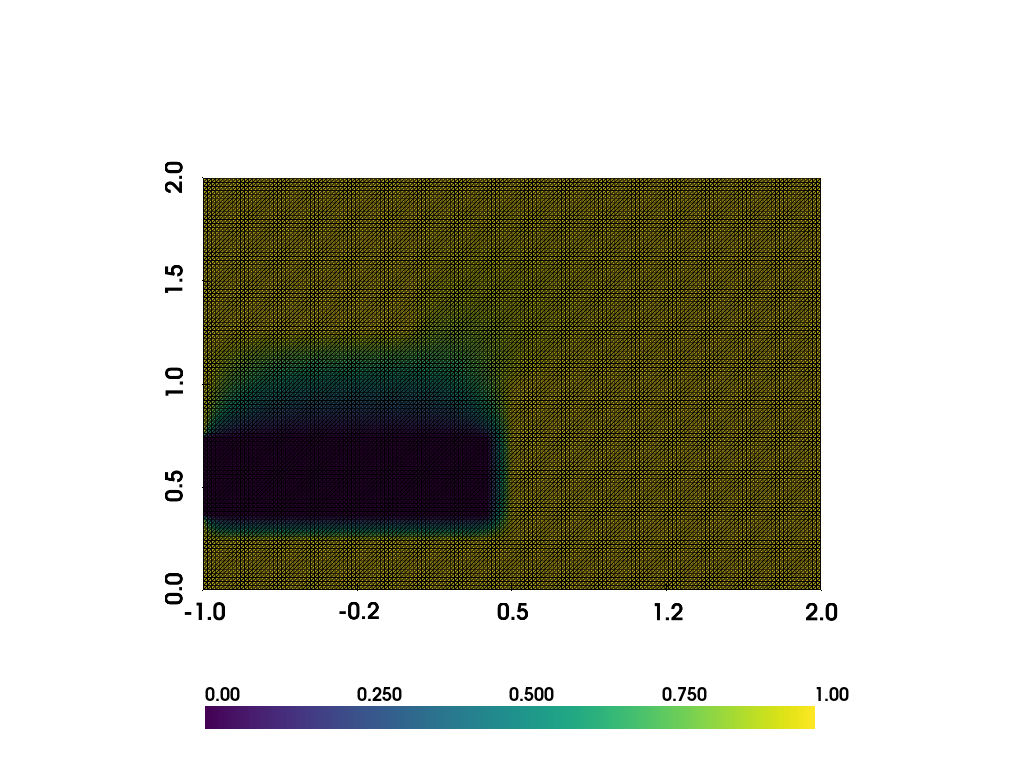

In [ ]:
# Specify the number of triangles in each dimension
num_triangles_x = 150
num_triangles_y = 100

clbf = Quadrotor2DHarmonicPotential(num_triangles_x=num_triangles_x,num_triangles_y=num_triangles_y)
clbf2 = Quadrotor2DHarmonicPotential(f_val=-6,num_triangles_x=num_triangles_x,num_triangles_y=num_triangles_y) # Not needed, just aids in visual
clbf.plot_solution_with_trajectory(show_edges=True)

In [ ]:
from math import sin, cos
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


# Constants
g     = 9.81    # Gravitational acceleration (m/s^2)
m     = 0.033    # Mass (kg)
Ixx   = 2.31e-05 # Mass moment of inertia (kg*m^2)
L     = 0.046/np.sqrt(2)   # Arm length (m)

# Returns the desired position, velocity, and acceleration at a given time.
# Trajectory is a step (y changes from 0 to 0.5 at t=1)
#
# t     : Time (seconds), scalar
# return: Desired position & velocity & acceleration, y, z, vy, vz, ay, az
def trajectory(x,t):
    # y,z = find_midpoint(x[0],x[1])
    y = 0
    z = 0
    k = 0.1
    vy, vz = clbf.evaluate_gradient(x[0],x[1])
    if vy**2+vz**2 > 0:
        vy, vz = -vy*k/np.sqrt(vy**2+vz**2),-vz*k/np.sqrt(vy**2+vz**2)
    else:
        vy, vz = -vy, -vz
    # vy = 0
    # vz = 0
    ay = 0
    az = 0

    return y, z, vy, vz, ay, az


# Returns force and moment to achieve desired state given current state.
# Calculates using PD controller.
#
# x     : Current state, [y, z, phi, vy, vz, phidot]
# y_des : desired y
# z_des : desired z
# vy_des: desired y velocity
# vz_des: desired z velocity
# ay_des: desired y acceleration
# az_des: desired z acceleration
# return: Force and moment to achieve desired state
def controller(x, y_des, z_des, vy_des, vz_des, ay_des, az_des):
    Kp_y   = 0.4
    Kv_y   = 1.0
    Kp_z   = 0.4
    Kv_z   = 1.0
    Kp_phi = 18
    Kv_phi = 15

    Kp_y, Kp_z = 0.0, 0.0
    
    phi_c = -1/g * (ay_des + Kv_y * (vy_des - x[3]))# + Kp_y * (y_des - x[0]))
    F = m * (g + az_des + Kv_z * (vz_des - x[4]))# + Kp_z * (z_des - x[1]))
    M = Ixx * (Kv_phi * (-x[5]) + Kp_phi * (phi_c - x[2]))

    return F, M


# Limit force and moment to prevent saturating the motor
# Clamp F and M such that u1 and u2 are between 0 and 1.7658
#
#    u1      u2
#  _____    _____
#    |________|
#
# F = u1 + u2
# M = (u2 - u1)*L
def clamp(F, M):
    u1 = 0.5*(F - M/L)
    u2 = 0.5*(F + M/L)
    
    if u1 < 0 or u1 > 1.7658 or u2 < 0 or u2 > 1.7658:
        print(f'motor saturation {u1} {u2}')
    
    u1_clamped = min(max(0, u1), 1.7658)
    u2_clamped = min(max(0, u2), 1.7658)

    # u1_clamped = u1
    # u2_clamped = u2

    F_clamped = u1_clamped + u2_clamped
    M_clamped = (u2_clamped - u1_clamped) * L

    return F_clamped, M_clamped


# Equation of motion
# dx/dt = f(t, x)
#
# t     : Current time (seconds), scalar
# x     : Current state, [y, z, phi, vy, vz, phidot]
# return: First derivative of state, [vy, vz, phidot, ay, az, phidotdot]
def xdot(t, x):
    # print(t)
    if x[0] < 0.4 and x[1] < 0.75:
        return [0,0,0,0,0,0]
    y_des, z_des, vy_des, vz_des, ay_des, az_des = trajectory(x,t)
    F, M = controller(x, y_des, z_des, vy_des, vz_des, ay_des, az_des)
    F_clamped, M_clamped = clamp(F, M)

    # First derivative, xdot = [vy, vz, phidot, ay, az, phidotdot]
    return [x[3],
            x[4],
            x[5],
            -F_clamped * sin(x[2]) / m,
            F_clamped * cos(x[2]) / m - g,
            M_clamped / Ixx]

def simulate(x0=None):
    if x0 is None:
        x0 = [np.random.uniform(1.4,1.6),
            np.random.uniform(0.3,1.0), 
            np.random.uniform(-0.05,0.05), 
            np.random.uniform(-0.01,0.01), 
            np.random.uniform(-0.01,0.01), 
            np.random.uniform(-0.01,0.01)] # Initial state [y0, z0, phi0, vy0, vz0, phidot0]
    print(x0)
    t_span = [0, 2000]            # Simulation time (seconds) [from, to]

    # Solve for the states, x(t) = [y(t), z(t), phi(t), vy(t), vz(t), phidot(t)]
    sol = solve_ivp(xdot, t_span, x0, method="RK45")
    return sol


# # Plot
# fig, axs = plt.subplots(3)
# axs[0].plot(sol.t, sol.y[0]) # y   vs t
# axs[1].plot(sol.t, sol.y[1]) # z   vs t
# axs[2].plot(sol.t, sol.y[2]) # phi vs t
# plt.show()



No module named 'trame'

Falling back to a static output.
  warnings.warn(



[1.5, 0.3, 0, 0, 0, 0]


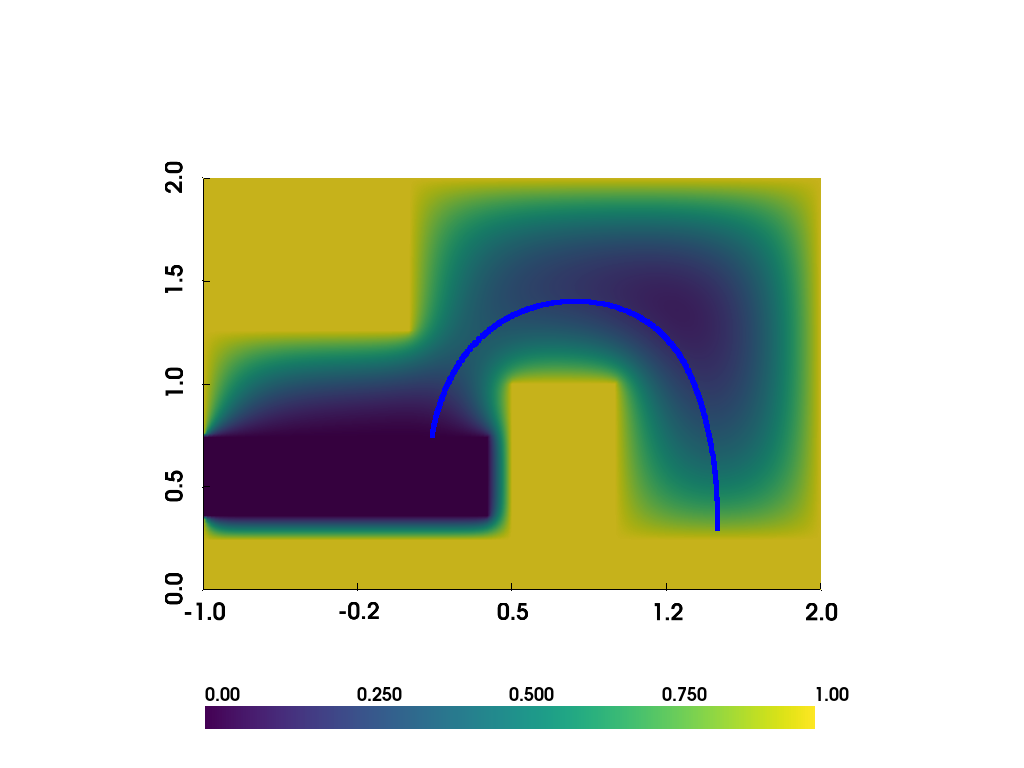

In [4]:
sol = simulate([1.5,0.3,0,0,0,0])
trajs = []
trajs.append(sol.y[:3,:].T)

clbf2.plot_solution_with_trajectory(trajs,show_edges=False)

In [5]:
sol.y[1,:] < 0.75

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [6]:
a = sol.t[sol.y[1,:] < 0.75]
min(a[a>10])

26.210781502368125

[1.5254731110865025, 0.5596118213921049, 0.03470512192156691, -0.00011529408980162116, -0.004588039408628397, 0.004470196529165199]
[1.4987114418774392, 0.4977030332564899, -0.013682893734328981, -0.0030806805061212427, 0.00481989236124236, -0.0016632917204883867]
[1.4004413939396474, 0.832269872702736, -0.046280516334881366, -0.004658483045892002, -0.006017369098503145, -0.002181408345682409]
[1.50570446978021, 0.3219315500631385, 0.043809595755207334, 0.005767947099987366, 0.004566544452284247, -0.002464463834612793]
[1.5297575943410378, 0.8633806674451594, -0.01028602210296621, 0.007729034071678421, -0.006872914389032852, -0.0019709012968538824]
[1.5952250858213017, 0.5704911071700551, -0.006387140953491979, 0.0048951156608104986, 0.0044643923337432875, -0.009329690067499626]
[1.4021612086543045, 0.9193644989845318, 0.0032465179218397616, -0.0024169279216432523, 0.005321265520639957, 0.006014718932658135]
[1.408103296705496, 0.4243231990621803, -0.03204509501849069, -0.0052885173370


No module named 'trame'

Falling back to a static output.
  warnings.warn(



23.917918245781454
1.8959677856940778


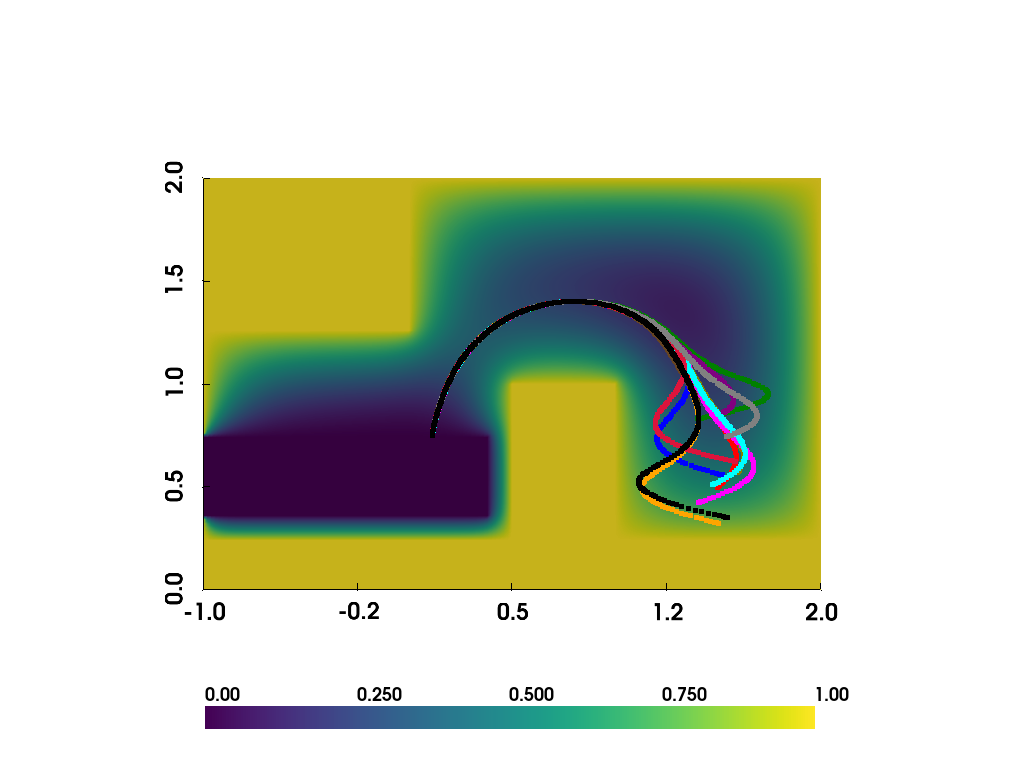

In [7]:
trajs = []
times = []
for i in range(12):
    sol = simulate()
    a = sol.t[sol.y[1,:] < 0.75]
    times.append(min(a[a>10]))
    trajs.append(sol.y[:3,:].T)
print(np.mean(times))
print(np.std(times))
clbf2.plot_solution_with_trajectory(trajs,show_edges=False,fig_name="quad2d_2_sol.eps")